***1. Install dependencies***

In [1]:
!pip install yfinance pandas numpy scikit-learn matplotlib

***2. Import libraries***

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

***3. Load stock data (Apple example)***

In [3]:
stock = "AAPL"

df = yf.download(stock, start="2015-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_1810/3813152741.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400
2015-01-05,23.511063,24.042136,23.325188,23.962475,257142000
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
2015-01-07,23.842983,23.942559,23.610638,23.721278,160423600
2015-01-08,24.759077,24.816610,24.053192,24.170472,237458000


***4. Feature selection (IMPORTANT STEP)***

We use:

Open
High
Low
Volume

Target:

**Next day Close (shifted)**

In [4]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# target = next day's close
df['Target'] = df['Close'].shift(-1)

df = df.dropna()

***5. Define X and y***

In [5]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

***6. Train-test split (NO TIME LEAKAGE FIX)***

In [6]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

***7. Train Model (Linear Regression baseline)***

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

***8. Predictions***

In [8]:
predictions = model.predict(X_test)

***9. Evaluation***

In [9]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

RMSE: 2.7256672527135652


***10. Plot Actual vs Predicted***

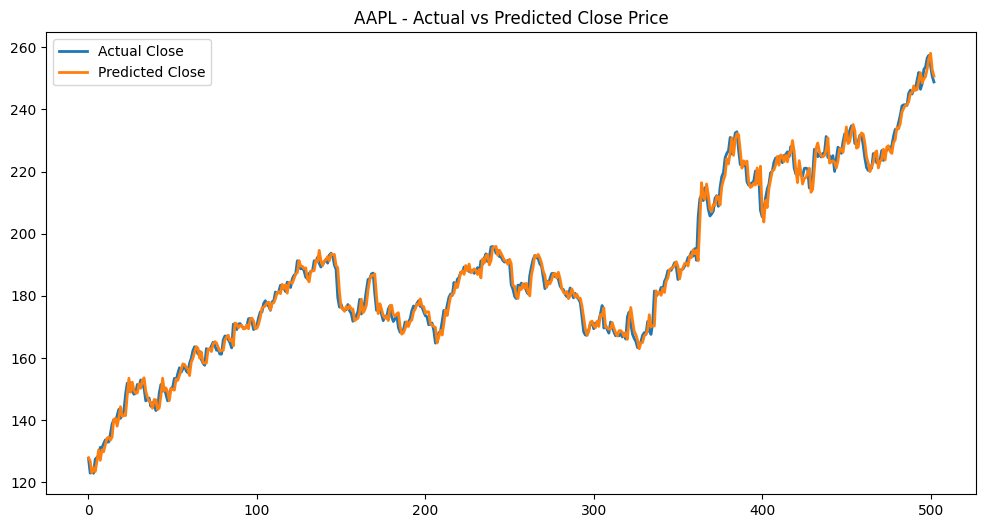

In [10]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Close", linewidth=2)
plt.plot(predictions, label="Predicted Close", linewidth=2)
plt.title(f"{stock} - Actual vs Predicted Close Price")
plt.legend()
plt.show()